In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ISLP import load_data
from ISLP.models import (summarize, poly)
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn import metrics
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import f_regression
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


# Let's start exploring the data.

In [58]:
data = load_data("Wage")

df = pd.DataFrame(data)
df2 = pd.DataFrame(data)
df.dropna(inplace=True)
# sns.heatmap(df.corr())
df.head()

,year,age,maritl,race,education,region,jobclass,health,health_ins,logwage,wage
0,2006,18,1. Never Married,1. White,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,4.318063,75.043154
1,2004,24,1. Never Married,1. White,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,2. No,4.255273,70.476020
2,2003,45,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,1. <=Good,1. Yes,4.875061,130.982177
3,2003,43,2. Married,3. Asian,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,5.041393,154.685293
4,2005,50,4. Divorced,1. White,2. HS Grad,2. Middle Atlantic,2. Information,1. <=Good,1. Yes,4.318063,75.043154


<Axes: >

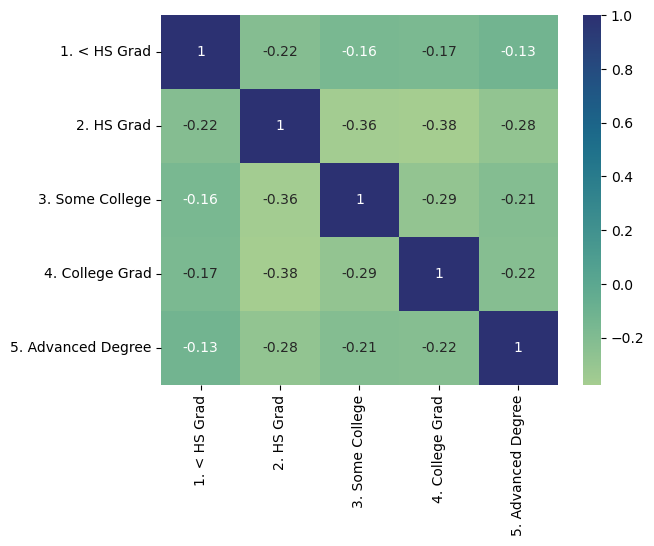

In [3]:
df["education"].unique()

education_table_numeric = pd.get_dummies(df["education"])

sns.heatmap(education_table_numeric.corr(), annot=True, cmap="crest")


In [4]:
for col in df.columns:
    print(df[col].name, len(df[col].unique()), df[col].dtype)

year 7 int64
age 61 int64
maritl 5 category
race 4 category
education 5 category
region 1 category
jobclass 2 category
health 2 category
health_ins 2 category
logwage 508 float64
wage 508 float64


## A lot of category columns which contain only few categorical vals. This means it is time to proceed binarization to include more columns in ML model

In [5]:
df.drop(columns="region", inplace=True)

In [6]:
jobclass = pd.get_dummies(df["jobclass"])
jobclass = jobclass.astype(int)
jobclass.columns = ["Jobclass Industrial", "Jobclass Information"]
jobclass.head()

df.drop(columns="jobclass", inplace=True)
df = pd.concat([df, jobclass], axis=1)

In [7]:
df.head()

,year,age,maritl,race,education,health,health_ins,logwage,wage,Jobclass Industrial,Jobclass Information
0,2006,18,1. Never Married,1. White,1. < HS Grad,1. <=Good,2. No,4.318063,75.043154,1,0
1,2004,24,1. Never Married,1. White,4. College Grad,2. >=Very Good,2. No,4.255273,70.476020,0,1
2,2003,45,2. Married,1. White,3. Some College,1. <=Good,1. Yes,4.875061,130.982177,1,0
3,2003,43,2. Married,3. Asian,4. College Grad,2. >=Very Good,1. Yes,5.041393,154.685293,0,1
4,2005,50,4. Divorced,1. White,2. HS Grad,1. <=Good,1. Yes,4.318063,75.043154,0,1


In [8]:
health = pd.get_dummies(df["health"])
health = health.astype(int)
health.columns = ["Health good", "Health very good"]

df.drop(columns="health", inplace=True)
df = pd.concat([df, health], axis=1)

In [9]:
health_ins = pd.get_dummies(df["health_ins"])
health_ins = health_ins.astype(int)
health_ins.columns = ["health_ins_yes", "health_ins_no"]
df.drop(columns="health_ins", inplace=True)
df = pd.concat([df, health_ins], axis=1)

In [10]:
df.head()

,year,age,maritl,race,education,logwage,wage,Jobclass Industrial,Jobclass Information,Health good,Health very good,health_ins_yes,health_ins_no
0,2006,18,1. Never Married,1. White,1. < HS Grad,4.318063,75.043154,1,0,1,0,0,1
1,2004,24,1. Never Married,1. White,4. College Grad,4.255273,70.476020,0,1,0,1,0,1
2,2003,45,2. Married,1. White,3. Some College,4.875061,130.982177,1,0,1,0,1,0
3,2003,43,2. Married,3. Asian,4. College Grad,5.041393,154.685293,0,1,0,1,1,0
4,2005,50,4. Divorced,1. White,2. HS Grad,4.318063,75.043154,0,1,1,0,1,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   year                  3000 non-null   int64   
 1   age                   3000 non-null   int64   
 2   maritl                3000 non-null   category
 3   race                  3000 non-null   category
 4   education             3000 non-null   category
 5   logwage               3000 non-null   float64 
 6   wage                  3000 non-null   float64 
 7   Jobclass Industrial   3000 non-null   int64   
 8   Jobclass Information  3000 non-null   int64   
 9   Health good           3000 non-null   int64   
 10  Health very good      3000 non-null   int64   
 11  health_ins_yes        3000 non-null   int64   
 12  health_ins_no         3000 non-null   int64   
dtypes: category(3), float64(2), int64(8)
memory usage: 243.9 KB


In [12]:
df_categorized = df.iloc[:, 2:5]
df_categorized.head()
df_numeric = df.drop(columns=["maritl", "race", "education"])


# Now I will see correlations only numeric cols. Later I will take care of category dtype cols.

<Axes: >

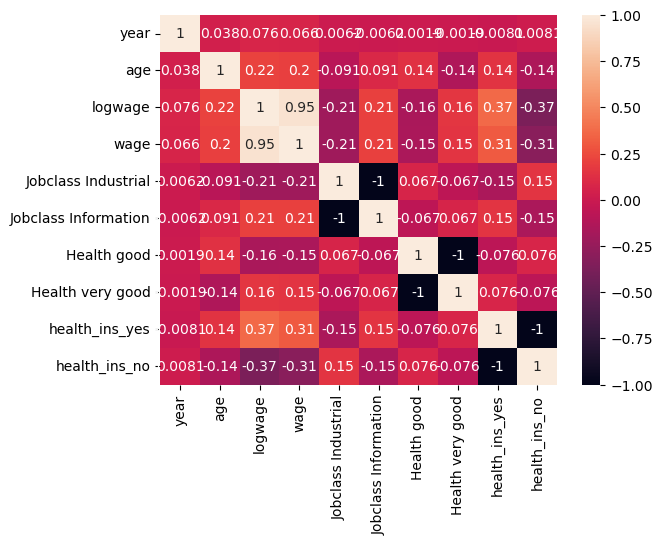

In [13]:
sns.heatmap(df_numeric.corr(), annot=True)

It is clear that after binarization of columns the values from the same column will head in the opposite direction. Logwage and wage is strongly correlated, because it is the same but differentially scaled. Besides that there is no strong LINEAR correlation.

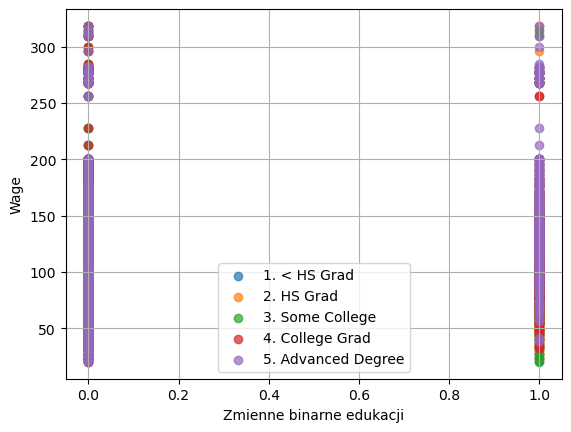

In [14]:
# df_education = pd.concat([education_table_numeric, df["wage"]], axis=1)

for col in education_table_numeric.columns:
    plt.scatter(education_table_numeric[col], df["wage"], label=col, alpha=.7) 

plt.legend()
plt.xlabel("Zmienne binarne edukacji")
plt.ylabel("Wage")
plt.grid()
plt.show()

# Plot above shows almost nothing. 

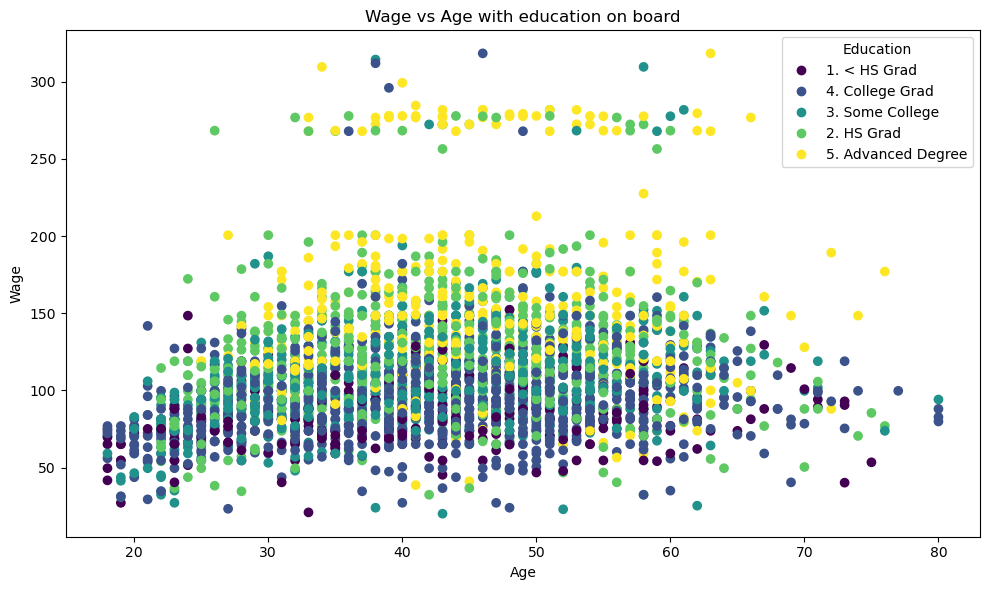

In [15]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df["age"], df["wage"], c=df["education"].astype('category').cat.codes)

plt.xlabel("Age")
plt.ylabel("Wage")
plt.title("Wage vs Age with education on board")

handles, labels = scatter.legend_elements(prop="colors")
plt.legend(handles, df["education"].unique(), title="Education")


plt.tight_layout()
plt.show()

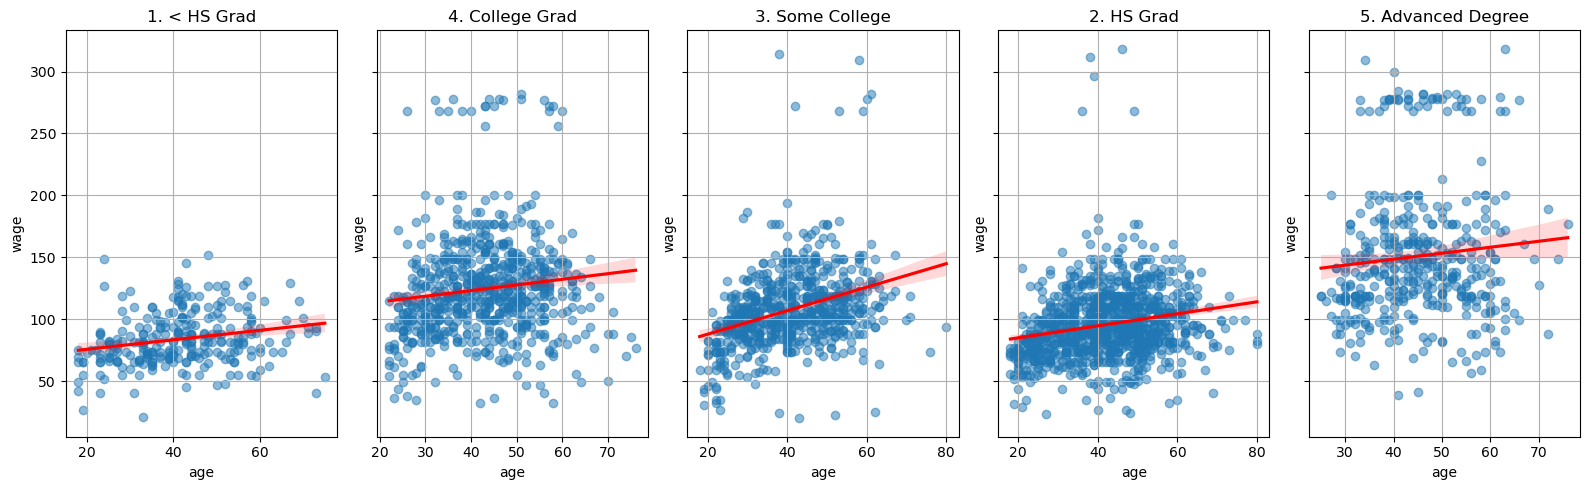

In [16]:
edu_levels = df["education"].unique()
fig, axes = plt.subplots(1, len(edu_levels), figsize=(16, 5), sharey=True)

for ax, level in zip(axes, edu_levels):
    temp = df[df["education"] == level]
    sns.regplot(
        data=temp,
        x="age",
        y="wage",
        ax=ax,
        scatter_kws={"alpha": 0.5},
        line_kws={"color": "red"}
    )
    ax.set_title(level)
    ax.grid()

plt.tight_layout()
plt.show()

In [19]:
X = df["age"].to_numpy()[:, np.newaxis]
y = df["wage"].to_numpy()[:, np.newaxis]

results = []
for i in range(10):
    model = Pipeline([("poly", PolynomialFeatures(degree=i)), ("linear", LinearRegression())])
    model.fit(X, y)
    score = cross_val_score(model, X, y, cv=5, scoring="r2")
    results.append(np.mean(score))
print(results)
print(np.where(results == np.max(results)))

[np.float64(-0.0010865686198882952), np.float64(0.03710503264264446), np.float64(0.08024722002760191), np.float64(0.08312462934678037), np.float64(0.08355308129780695), np.float64(0.0825809462091334), np.float64(0.08298309472963154), np.float64(0.0836189856271637), np.float64(0.08327539621987556), np.float64(0.08073596045864566)]
(array([7]),)


In [20]:
# models for anova
models =[]
for i in range(10):
    poly = PolynomialFeatures(degree=i)
    X_pol = poly.fit_transform(X)
    model = sm.GLS(y, X_pol).fit()
    models.append(model)

In [21]:
# Hypothesis test ANOVA
sm.stats.anova_lm(models[0], models[1], models[2],models[3], models[4], models[5], models[6])

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,2999.0,5.222086e+06,0.0,NaN,NaN,NaN
1,2998.0,5.022216e+06,1.0,199869.664970,125.505882,1.444930e-28
2,2997.0,4.793430e+06,1.0,228786.010128,143.663571,2.285169e-32
3,2996.0,4.777674e+06,1.0,15755.693664,9.893609,1.674794e-03
4,2995.0,4.771604e+06,1.0,6070.152124,3.811683,5.098933e-02
5,2994.0,4.770322e+06,1.0,1282.563017,0.805371,3.695646e-01
6,2993.0,4.766389e+06,1.0,3932.257586,2.469216,1.162015e-01


I chose optimal degree = 3, because of the Pr>F which tells us if adding 1 more polynomial is statistically important and 4th polynomial is above the 5% rate. And by that there is no need to include extra redundant degrees. It is more safe to reduce complexity.

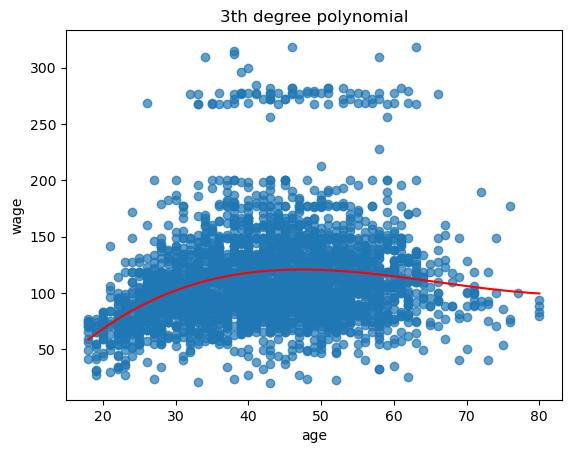

In [22]:
opt_degree = 3
model = Pipeline([('poly', PolynomialFeatures(degree = opt_degree)), ('linear', LinearRegression())])
model.fit(X,y)


X_lin = np.linspace(df["age"].min(), df["age"].max())[:,np.newaxis]
y_lin = model.predict(X_lin)

plt.scatter(X,y, alpha=0.7)
plt.plot(X_lin, y_lin,'-r');
plt.title("3th degree polynomial")
plt.xlabel("age")
plt.ylabel("wage")
plt.show()

b) ~ Step function in use

In [53]:
pipe = Pipeline([
    ('discretizer', KBinsDiscretizer(encode='onehot-dense', strategy='uniform')),
    ('linreg', LinearRegression())
])

params = {
        "discretizer__n_bins": [3, 5, 10,15,20],
        "discretizer__strategy": ['uniform', 'quantile']
}


kfold = KFold(5, shuffle=True, random_state=1)

cv_results = GridSearchCV(pipe, params, cv=kfold).fit(df[["age"]].values, y)
cv_results.best_params_

{'discretizer__n_bins': 20, 'discretizer__strategy': 'quantile'}

In [54]:
best_est = cv_results.best_estimator_
best_params = cv_results.best_params_["discretizer__n_bins"]
best_params

20

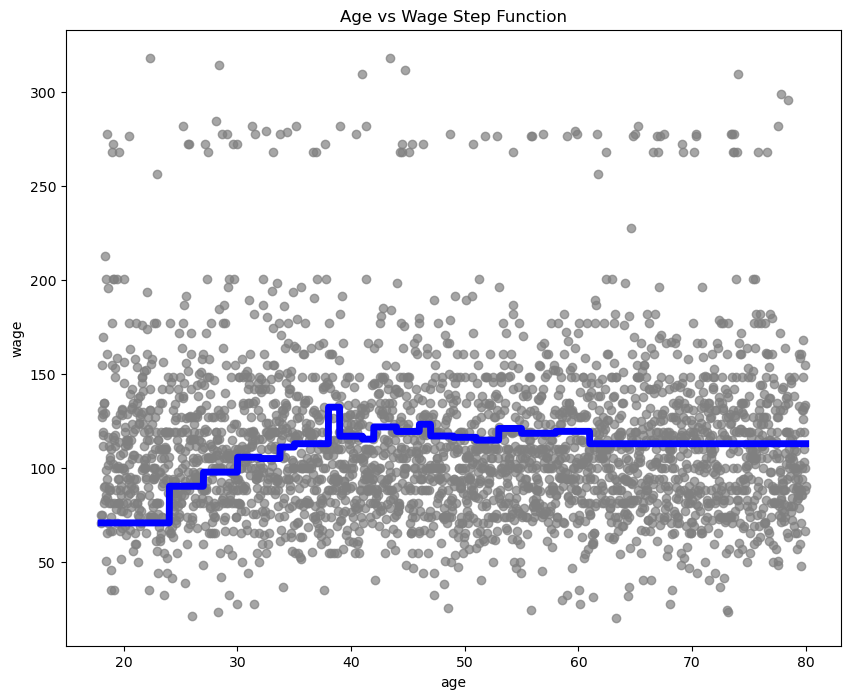

In [55]:
age = np.linspace(df["age"].min(), df["age"].max(), 3000).reshape(-1, 1)
best_predicted_step = best_est.predict(age)

fig, ax = plt.subplots(figsize=(10,8))
ax.scatter(age, y, facecolor='gray', alpha=0.7)

ax.plot(age, best_predicted_step, 'blue', linewidth=5,)

ax.set_title('Age vs Wage Step Function')
ax.set_xlabel('age')
ax.set_ylabel('wage')
plt.show()

it looks very overfitted. Too many steps.

0          1. < HS Grad
1       4. College Grad
2       3. Some College
3       4. College Grad
4            2. HS Grad
             ...       
2995    3. Some College
2996         2. HS Grad
2997       1. < HS Grad
2998    3. Some College
2999         2. HS Grad
Name: education, Length: 3000, dtype: category
Categories (5, object): ['1. < HS Grad' < '2. HS Grad' < '3. Some College' < '4. College Grad' < '5. Advanced Degree']

In [76]:
X = df2[['age', 'education']]
y = df2['wage']


bin_features = ColumnTransformer([
    ("age_bin", KBinsDiscretizer(n_bins=5, encode='onehot-dense', strategy='uniform'), ["age"]),
    ("education_ohe", OneHotEncoder(drop='first'), ["education"])  
])


pipe = Pipeline([
    ("preprocess", bin_features),
    ("interactions", PolynomialFeatures(interaction_only=True, include_bias=False)),
    ("reg", LinearRegression())
])



In [79]:
params = {
    "binning__age_bin__n_bins": [3, 5, 7],
    "binning__education_bin__n_bins": [2, 4, 6]
}

cv = KFold(n_splits=5, shuffle=True, random_state=1)

grid = GridSearchCV(pipe, params, cv=cv, scoring='r2')
pipe.fit(X, y)
preds = pipe.predict(X)

preds
# print(grid.best_params_)
# print("Best R2:", grid.best_score_)


array([ 75.3070313 , 103.41566578, 115.31522514, ...,  75.3070313 ,
        88.88806519,  99.96172501])